### 가이드북 코드 필사 - 지도 학습

#### 사용 알고리즘 : Denoising AutoEncoder

[Denoising AE]
- AE가 의미 있는 특성(feature)을 학습하도록 제약을 주는 방법
- 입력 데이터에 noise를 추가하고 noise가 없는 원본 입력을 복원하도록 학습시키는 것
    - `dropout`을 통해 잡음을 발생시킬 수 있음 ; 신경망 모델이 더 견고하고 안정적으로 학습할 수 있도록 도와줌
    - **단순히 입력을 출력으로 복사하지 못하므로 데이터에 있는 패턴을 찾게 되는 형식**

⭐️**정상 데이터로만 학습**된 잡음제거 AE의 경우, 학습한 적이 없는 불량 데이터가 입력으로 들어왔을 때보다 정상 데이터를 입력으로 받을 때 작은 복원 오차를 가지게 되어 불량 유무를 분류할 수 있게 됨

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

/Users/wheemin/Desktop/my_project/KAMP_AI제조데이터분석/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


#### 0. 데이터 특성 파악

In [7]:
# Load the labeled datasets
labeled_cn7 = pd.read_csv('../data/1. 사출성형기 AI 데이터셋/moldset_labeled_cn7.csv', index_col=0)
labeled_rg3 = pd.read_csv('../data/1. 사출성형기 AI 데이터셋/moldset_labeled_rg3.csv', index_col=0)

# head() to check the first few rows of the datasets
print("Labeled CN7 Dataset:")
print(display(labeled_cn7.head()))
print("\nLabeled RG3 Dataset:")
print(display(labeled_rg3.head()))

Labeled CN7 Dataset:


,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,0,1.679123,1.491397,-0.478017,0.361047,0.97858,-0.711164,1.532018,0.0,-1.152398,...,-0.533773,0.729073,-1.598068,-0.672350,-1.536620,0.008133,-1.352970,-1.780463,1.023094,1.287574
1,0,2.080358,1.894372,-0.527100,1.886261,0.97858,-0.711164,1.471608,0.0,-1.347095,...,-0.533773,0.056153,0.622557,0.914107,0.504051,-0.915098,-2.263700,-0.874018,1.023094,1.337339
2,0,2.080358,1.894372,-0.527100,1.886261,0.97858,-0.711164,1.471608,0.0,-1.347095,...,-0.533773,0.056153,0.622557,0.914107,0.504051,-0.915098,-2.263700,-0.874018,1.023094,1.337339
3,0,1.679123,1.894372,-0.527100,1.377857,0.97858,1.202502,1.471608,0.0,-1.347095,...,-0.533773,0.729073,-0.765355,1.231418,0.886706,-0.299626,0.013158,-1.176164,1.166162,1.337339
4,0,1.679123,1.894372,-0.527100,1.377857,0.97858,1.202502,1.471608,0.0,-1.347095,...,-0.533773,0.729073,-0.765355,1.231418,0.886706,-0.299626,0.013158,-1.176164,1.166162,1.337339


None

Labeled RG3 Dataset:


,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
1211,0,-0.029099,-1.192531,1.977737,0.249511,1.033078,2.867608,-1.755816,0.0,2.187583,...,-1.306878,0.096629,-0.496175,-0.002081,0.047749,0.282727,-0.354184,0.183232,-1.393485,-1.576042
1212,0,-0.029099,-1.192531,1.977737,0.249511,1.033078,2.867608,-1.755816,0.0,2.187583,...,-1.306878,0.096629,-0.496175,-0.002081,0.047749,0.282727,-0.354184,0.183232,-1.393485,-1.576042
1213,0,-0.029099,-1.192531,1.528778,0.249511,1.033078,2.075089,-0.192928,0.0,2.187583,...,-0.841877,0.562844,1.442567,-0.002081,0.340262,1.850096,-0.851297,0.183232,-1.535968,-1.576042
1214,0,-0.029099,-1.192531,1.528778,0.249511,1.033078,2.075089,-0.192928,0.0,2.187583,...,-0.841877,0.562844,1.442567,-0.002081,0.340262,1.850096,-0.851297,0.183232,-1.535968,-1.576042
1215,0,-0.029099,-1.192531,0.630880,-0.298708,1.033078,1.277707,-1.755816,0.0,1.402554,...,-1.539374,1.262095,-0.253813,-0.002081,0.925242,0.282727,-1.348485,0.284910,-1.535968,-1.576042


None


In [23]:
# Check the basic statistics of the datasets
print("CN7 Dataset Statistics:")
display(labeled_cn7.describe())
print("\nRG3 Dataset Statistics:")
display(labeled_rg3.describe())

CN7 Dataset Statistics:


,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
count,1211.000000,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1211.0,1.211000e+03,...,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03
mean,0.014038,-2.957172e-14,-5.351073e-15,6.477615e-15,5.069438e-14,-1.574811e-14,4.630532e-12,-3.628403e-14,0.0,3.238808e-15,...,-3.708200e-15,-1.824763e-14,-3.505774e-14,8.755635e-15,2.114319e-14,5.257195e-15,-3.579410e-14,-2.675537e-15,-8.214367e-16,-1.642873e-16
std,0.117696,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,0.0,1.000413e+00,...,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00
min,0.000000,-7.549091e+00,-7.776799e+00,-7.234252e-01,-3.706092e+00,-9.024657e-01,-2.613163e+00,-2.876962e+00,0.0,-1.541785e+00,...,-6.631852e+00,-2.635662e+00,-2.985979e+00,-2.893331e+00,-2.046826e+00,-4.607976e+00,-2.719099e+00,-2.082616e+00,-1.909796e+00,-1.648589e+00
25%,0.000000,-7.282486e-01,-5.234162e-01,-3.798495e-01,-6.557617e-01,-9.024657e-01,-7.111644e-01,-7.026540e-01,0.0,-5.683212e-01,...,-5.337734e-01,-6.168347e-01,-7.653547e-01,-3.550389e-01,-8.989006e-01,-6.073388e-01,-8.975711e-01,-8.740180e-01,-7.652542e-01,-7.528108e-01
50%,0.000000,-3.270136e-01,-1.204612e-01,-3.627368e-02,3.610475e-01,-9.024657e-01,-7.111644e-01,-6.422898e-01,0.0,1.575557e-02,...,2.284901e-01,5.615323e-02,6.735821e-02,-3.772821e-02,-6.117000e-03,8.132912e-03,1.315810e-02,-1.689960e-01,9.315350e-02,-1.556248e-01
75%,0.000000,8.766531e-01,6.854681e-01,2.091349e-01,3.610475e-01,9.785804e-01,1.202502e+00,1.471608e+00,0.0,4.051426e-01,...,6.096146e-01,7.290727e-01,6.225566e-01,5.968932e-01,8.867055e-01,6.236047e-01,4.685574e-01,7.374564e-01,1.094628e+00,1.287574e+00
max,1.000000,2.080358e+00,2.297327e+00,2.003846e+01,1.256247e+01,2.859537e+00,6.943503e+00,1.592429e+00,0.0,9.555703e+00,...,1.753017e+00,3.196558e+00,3.398379e+00,3.135185e+00,2.544760e+00,3.393298e+00,2.745415e+00,2.550354e+00,1.380764e+00,1.436870e+00



RG3 Dataset Statistics:


,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
count,1182.000000,1.182000e+03,1.182000e+03,1.182000e+03,1.182000e+03,1.182000e+03,1.182000e+03,1.182000e+03,1182.0,1.182000e+03,...,1.182000e+03,1.182000e+03,1.182000e+03,1.182000e+03,1.182000e+03,1.182000e+03,1.182000e+03,1.182000e+03,1.182000e+03,1.182000e+03
mean,0.021151,-4.715311e-14,-1.923635e-16,-1.760126e-14,5.502649e-14,4.972597e-14,2.788886e-12,1.813267e-13,0.0,-2.755607e-14,...,8.175449e-15,-4.461706e-14,4.473053e-14,2.130276e-14,4.068488e-14,-7.989849e-14,-2.174910e-14,-6.396087e-15,-3.847270e-16,4.809088e-17
std,0.143947,1.000423e+00,1.000423e+00,1.000423e+00,1.000423e+00,1.000423e+00,1.000423e+00,1.000423e+00,0.0,1.000423e+00,...,1.000423e+00,1.000423e+00,1.000423e+00,1.000423e+00,1.000423e+00,1.000423e+00,1.000423e+00,1.000423e+00,1.000423e+00,1.000423e+00
min,0.000000,-8.627730e+00,-1.192531e+00,-2.736231e+00,-1.395040e+00,-1.806725e+00,-1.911818e+00,-2.537409e+00,0.0,-2.522291e+00,...,-2.469375e+00,-3.166664e+00,-2.192629e+00,-2.460515e+00,-2.292216e+00,-4.419377e+00,-2.839975e+00,-3.070514e+00,-1.963415e+00,-2.061609e+00
25%,0.000000,-2.909945e-02,-1.192531e+00,-7.159559e-01,-2.987077e-01,-3.867898e-01,-1.114437e+00,-9.745206e-01,0.0,-9.522930e-01,...,-8.418767e-01,-6.026229e-01,-7.385359e-01,-6.167367e-01,-9.759549e-01,-6.577509e-01,-8.512967e-01,-5.285282e-01,-8.235546e-01,-8.476893e-01
50%,0.000000,-2.909945e-02,8.385523e-01,-4.253793e-02,2.495107e-01,-3.867898e-01,-3.170554e-01,-1.929275e-01,0.0,-1.673838e-01,...,8.812514e-02,9.662861e-02,-1.145227e-02,-2.081321e-03,4.774926e-02,-3.076530e-02,1.430047e-01,8.154669e-02,1.738253e-01,2.053097e-03
75%,0.000000,-2.909945e-02,8.385523e-01,6.308800e-01,2.495107e-01,1.033078e+00,4.803259e-01,5.883674e-01,0.0,6.176452e-01,...,7.856221e-01,5.628437e-01,7.155574e-01,3.052464e-01,9.252418e-01,5.962203e-01,6.401933e-01,7.933072e-01,9.930992e-01,1.094583e+00
max,1.000000,8.569634e+00,8.385523e-01,3.773533e+00,1.176189e+01,1.033078e+00,2.867608e+00,2.932550e+00,0.0,2.187583e+00,...,2.180616e+00,2.660669e+00,3.139022e+00,2.456353e+00,2.095202e+00,4.357847e+00,2.628796e+00,2.115135e+00,1.598652e+00,1.822933e+00


In [12]:
# 양품과 불량품의 비율 확인
print("Pass/Fail Ratios in CN7 Dataset:")
print(labeled_cn7['PassOrFail'].value_counts(normalize=True))
print("Pass/Fail Ratios in RG3 Dataset:")
print(labeled_rg3['PassOrFail'].value_counts(normalize=True))

Pass/Fail Ratios in CN7 Dataset:
PassOrFail
0    0.985962
1    0.014038
Name: proportion, dtype: float64
Pass/Fail Ratios in RG3 Dataset:
PassOrFail
0    0.978849
1    0.021151
Name: proportion, dtype: float64


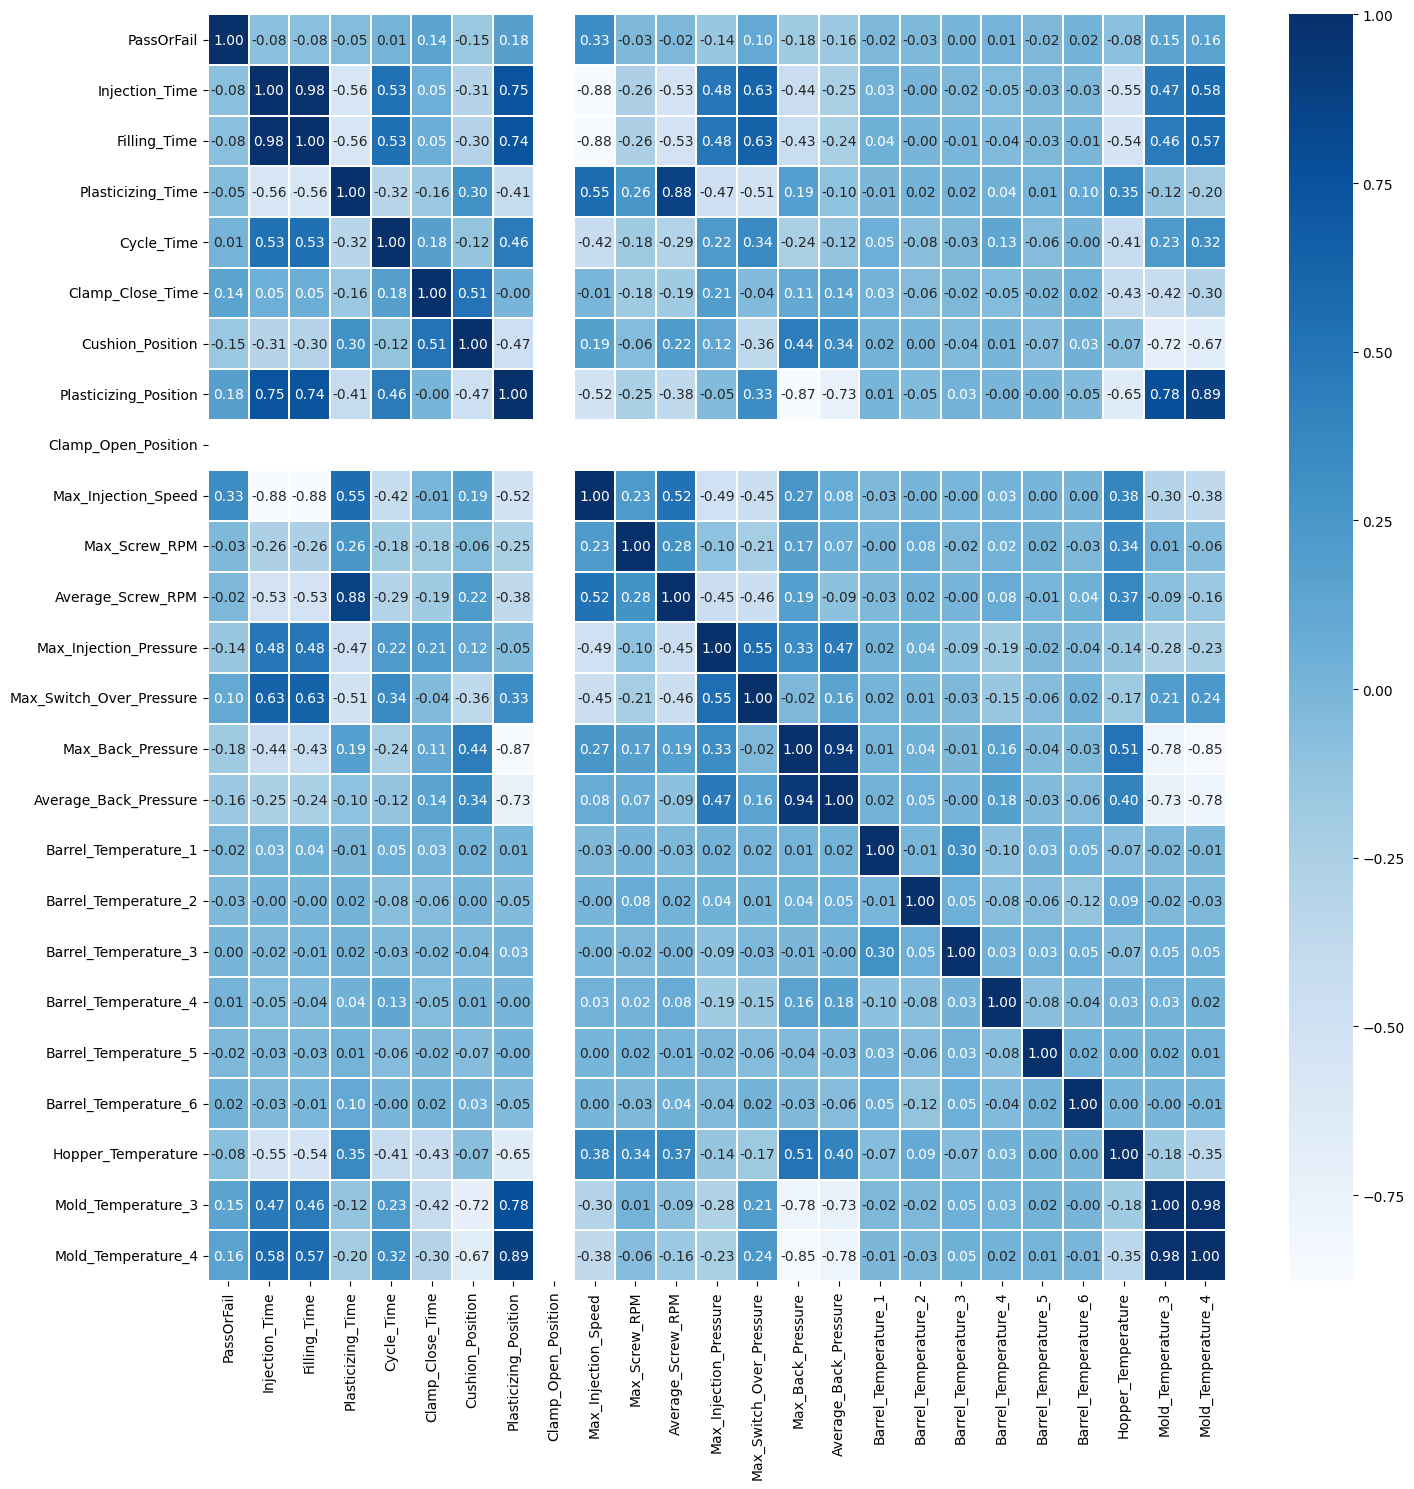

In [25]:
# 변수 간 상관관계 파악 (cn7에 대해서만)
# Clamp_Open_Position 상관관계 계산 불가 (값이 모두 0)
plt.subplots(figsize=(15, 15))
sns.heatmap(data=labeled_cn7.corr(), annot=True, fmt='.2f', cmap='Blues', linewidths=0.1)
plt.tight_layout()

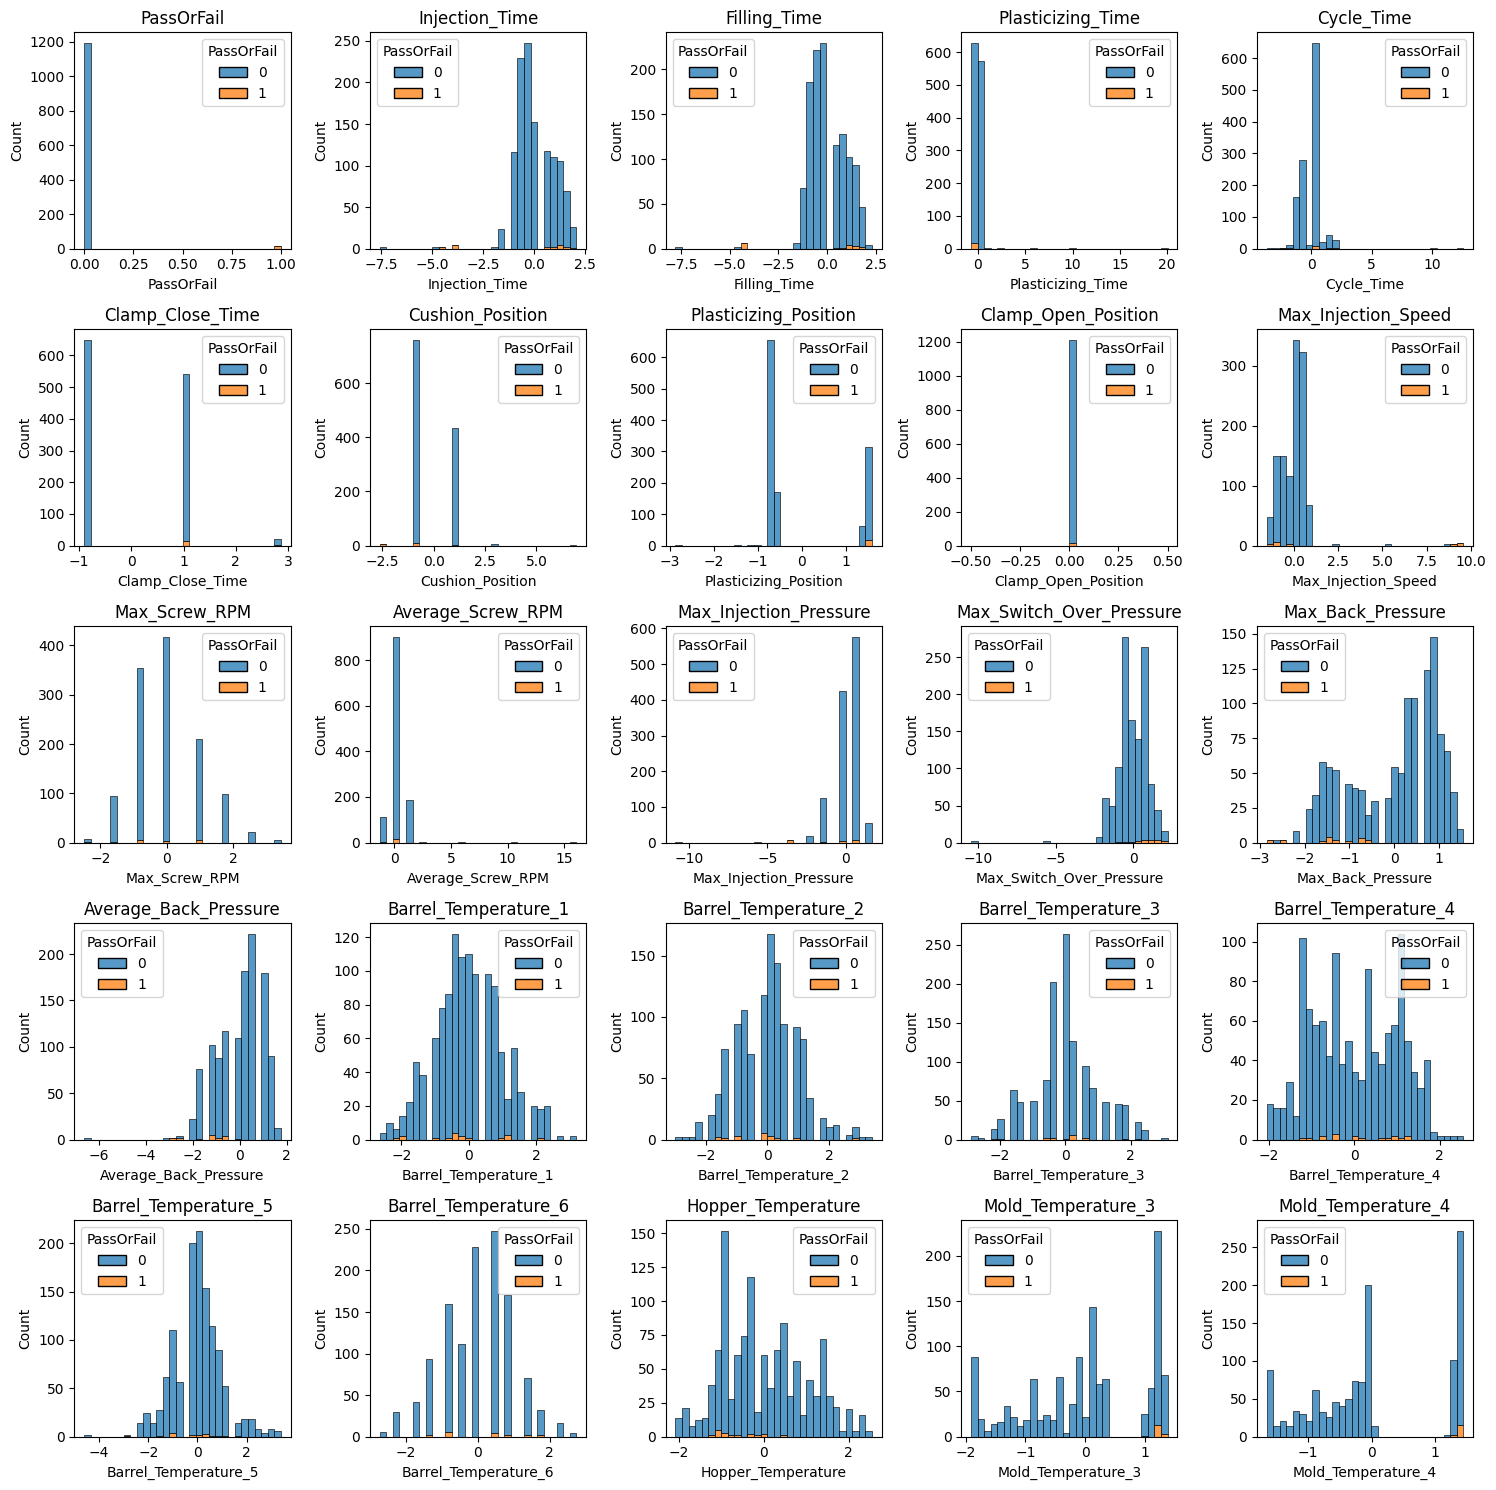

In [27]:
plt.figure(figsize=(15, 15))

for index, value in enumerate(labeled_cn7.columns):
    plt.subplot(5, 5, index + 1)
    sns.histplot(data=labeled_cn7, x=value, hue='PassOrFail', multiple='stack', bins=30)
    plt.title(value)

plt.tight_layout()

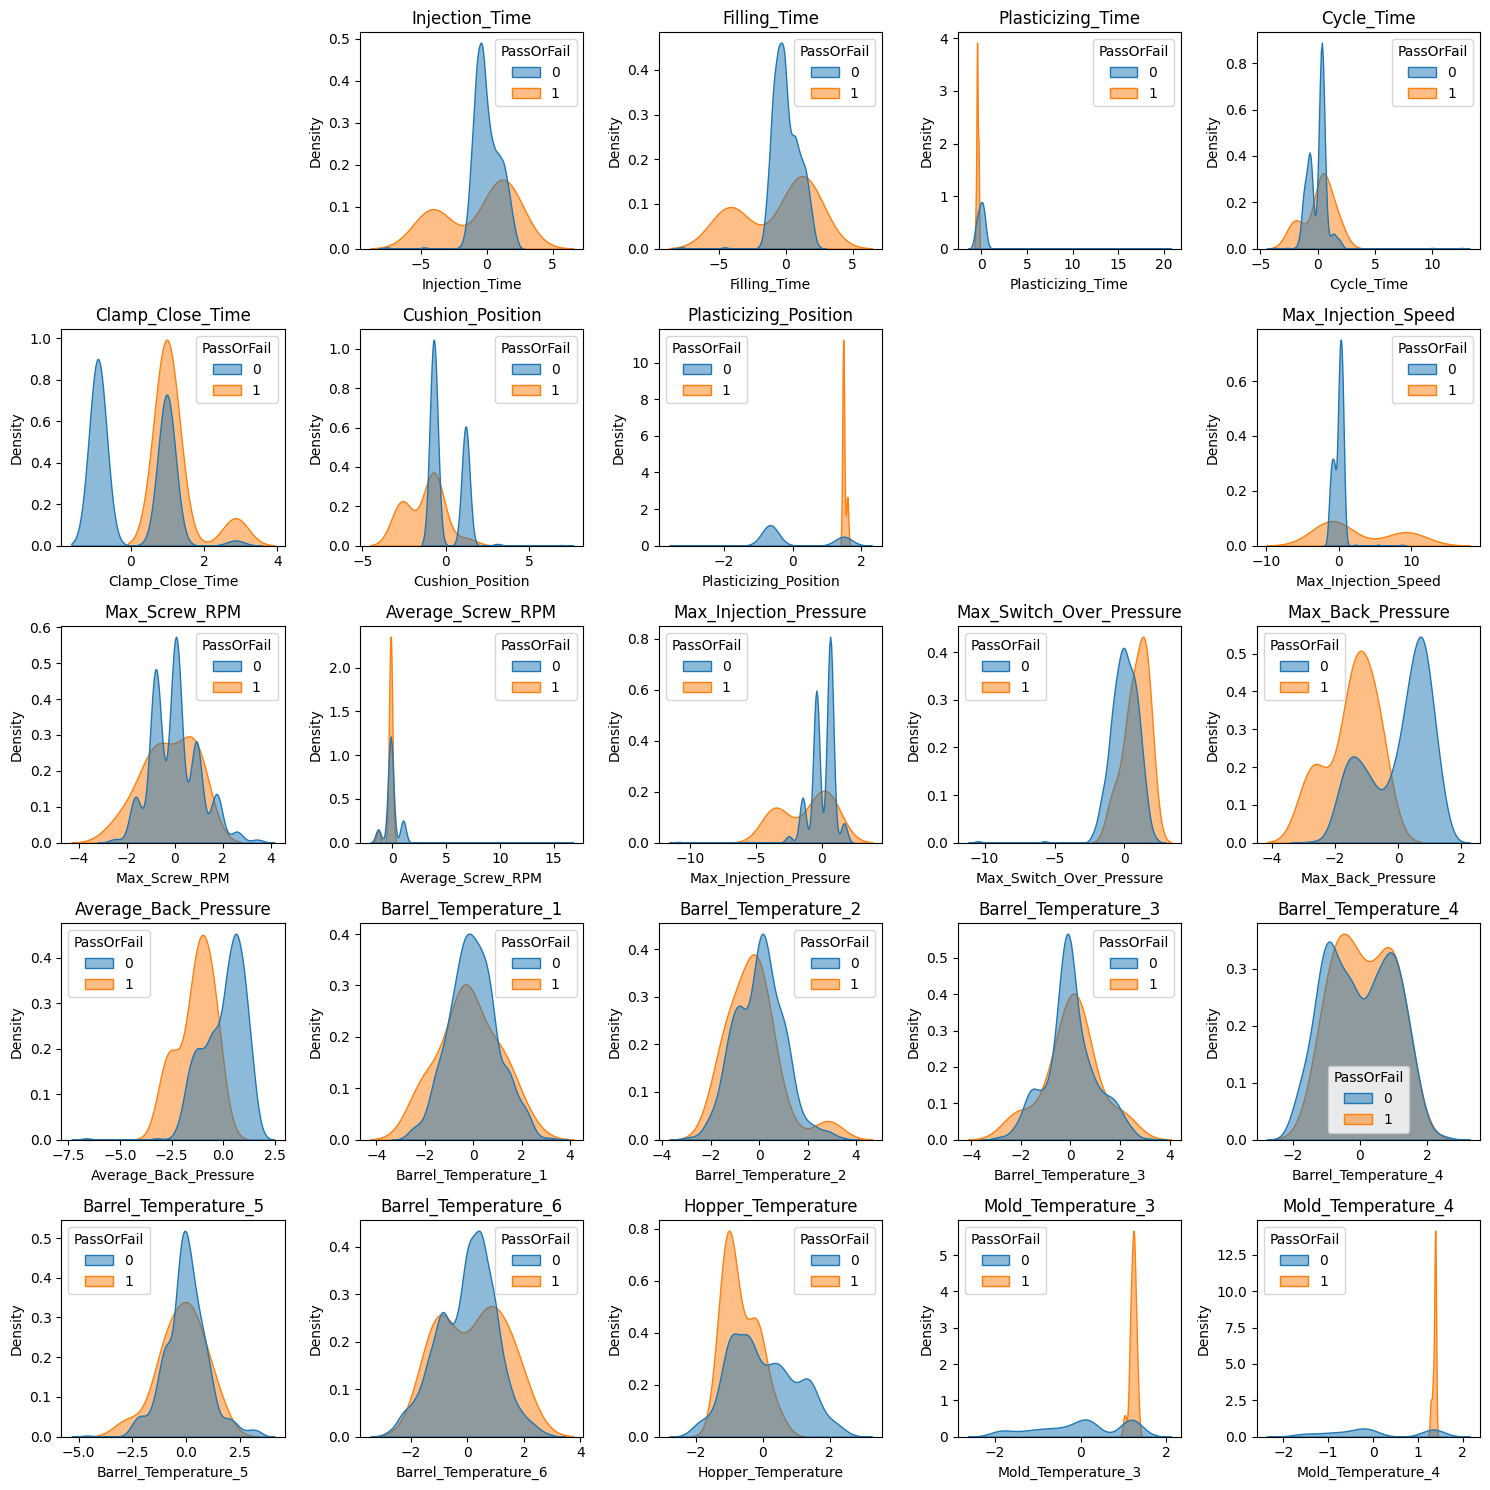

In [ ]:
# plot density plots for each feature in the CN7 dataset
# Normalize the density independently for each class (Pass/Fail) to better visualize the distribution differences
plt.figure(figsize=(15, 15))
for index, value in enumerate(labeled_cn7.columns):
    if value in ['PassOrFail','Clamp_Open_Position']:  # Skip the target variable and feature with no variance
        continue
    plt.subplot(5, 5, index + 1)
    sns.kdeplot(data=labeled_cn7, x=value, hue='PassOrFail', fill=True, common_norm=False, alpha=0.5)
    plt.title(value)
plt.tight_layout()

/var/folders/ld/s49c67nn0cb6hr1_s2647tsr0000gn/T/ipykernel_16210/584083989.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=labeled_rg3, x=value, hue='PassOrFail', fill=True, common_norm=False, alpha=0.5)


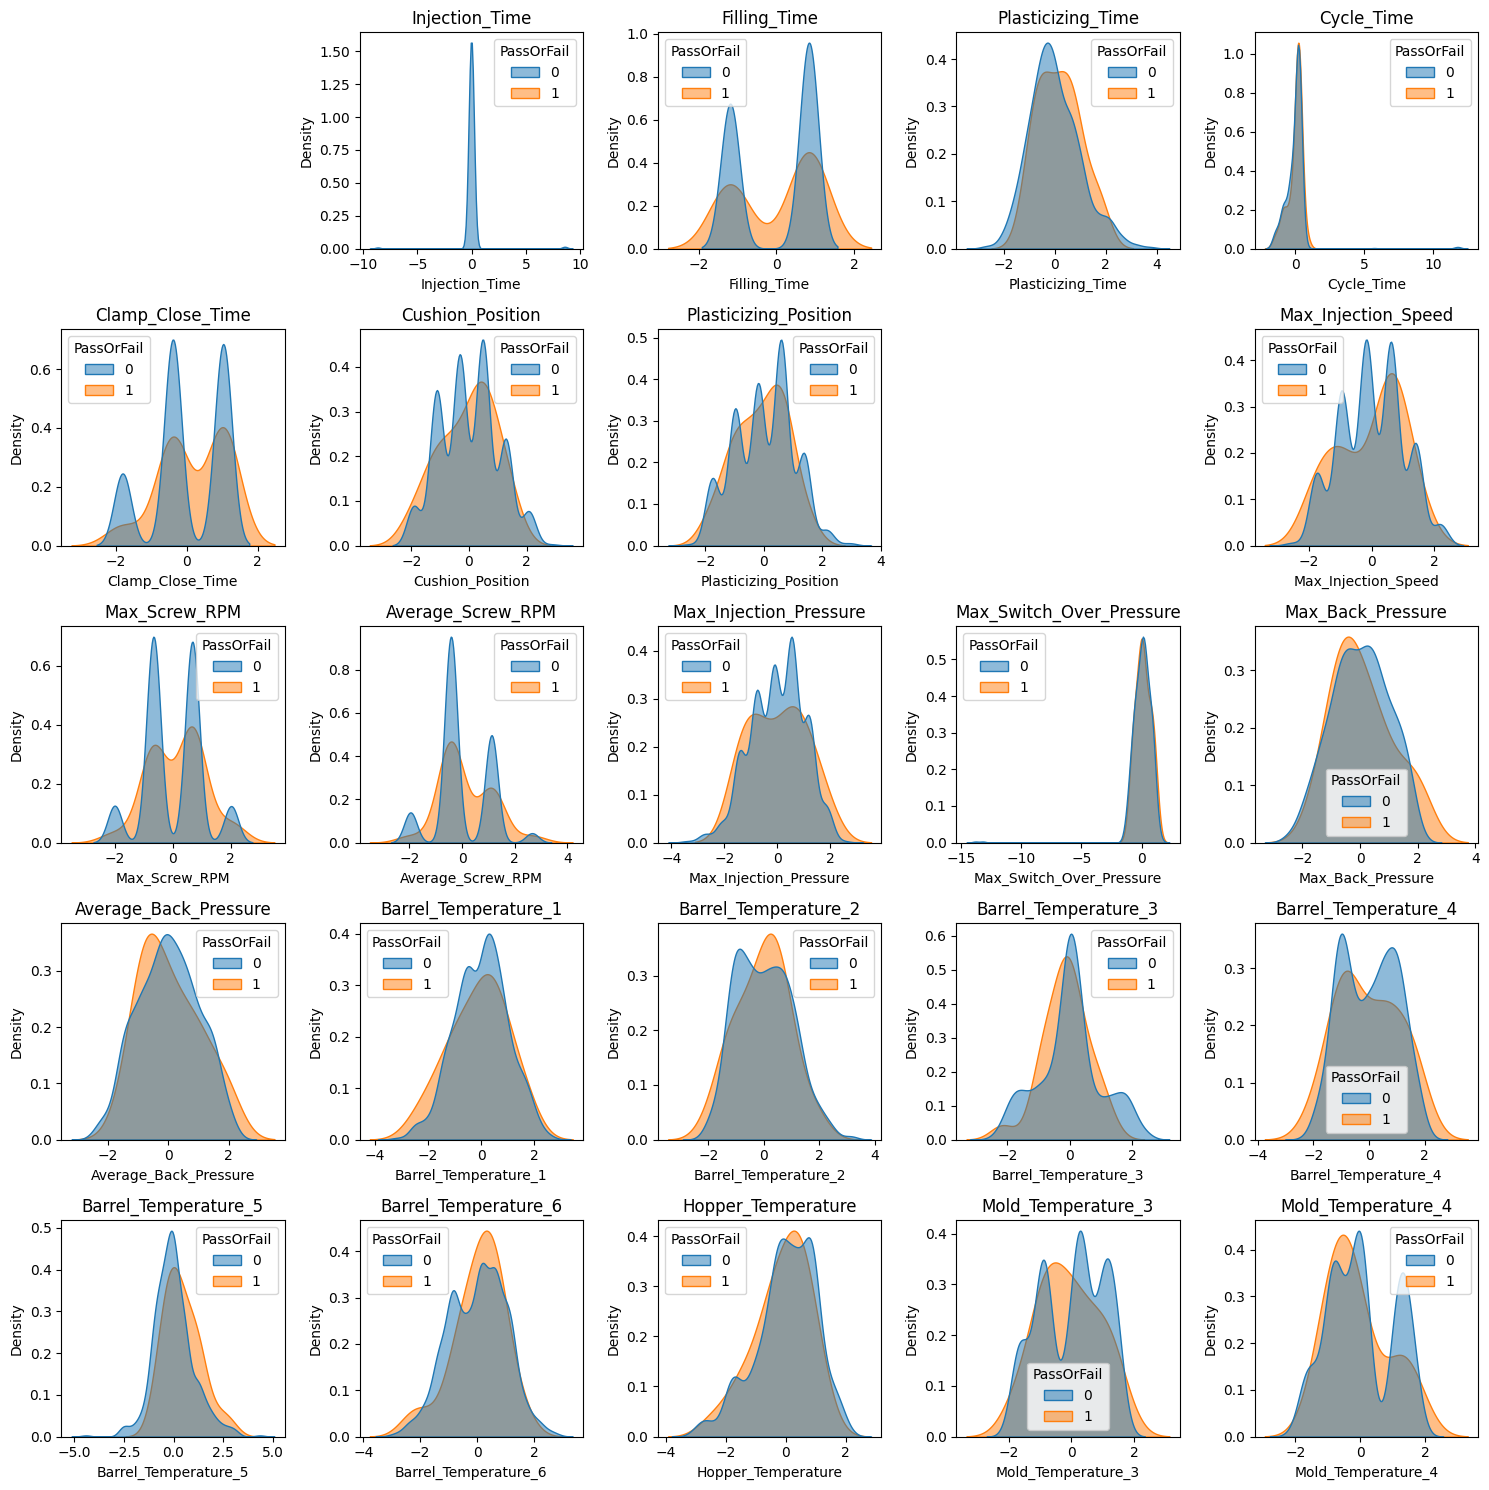

In [32]:
# Do the same thing for the RG3 dataset
plt.figure(figsize=(15, 15))
for index, value in enumerate(labeled_rg3.columns):
    if value in ['PassOrFail','Clamp_Open_Position']:  # Skip the target variable and feature with no variance
        continue
    plt.subplot(5, 5, index + 1)
    sns.kdeplot(data=labeled_rg3, x=value, hue='PassOrFail', fill=True, common_norm=False, alpha=0.5)
    plt.title(value)
plt.tight_layout()

#### 1. 학습/평가 데이터 분리

학습/평가 데이터 분리 방법
- 2가지 제품 각각 train/test set 분리
- 2가지 제품 모두 '양품'만 학습

![alt text](image.png)

In [37]:
# 양품(Y) 불량품(N) 분리
cn7_Y = labeled_cn7[labeled_cn7['PassOrFail'] == 0]
cn7_N = labeled_cn7[labeled_cn7['PassOrFail'] == 1]
print('CN7의 양품(Y) 개수:', len(cn7_Y))  # 처음 확인한 비율과 동일해야함
print('CN7의 불량품(N) 개수:', len(cn7_N))

rg3_Y = labeled_rg3[labeled_rg3['PassOrFail'] == 0]
rg3_N = labeled_rg3[labeled_rg3['PassOrFail'] == 1]
print('RG3의 양품(Y) 개수:', len(rg3_Y))
print('RG3의 불량품(N) 개수:', len(rg3_N))

CN7의 양품(Y) 개수: 1194
CN7의 불량품(N) 개수: 17
RG3의 양품(Y) 개수: 1157
RG3의 불량품(N) 개수: 25


In [38]:
# drop target variable
cn7_Y.drop(columns=['PassOrFail'], axis=1, inplace=True)
cn7_N.drop(columns=['PassOrFail'], axis=1, inplace=True)
rg3_Y.drop(columns=['PassOrFail'], axis=1, inplace=True)
rg3_N.drop(columns=['PassOrFail'], axis=1, inplace=True)

print("CN7 Y shape:", cn7_Y.shape)
print('RG3 Y shape:', rg3_Y.shape)

CN7 Y shape: (1194, 24)
RG3 Y shape: (1157, 24)


/var/folders/ld/s49c67nn0cb6hr1_s2647tsr0000gn/T/ipykernel_16210/2537010898.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cn7_Y.drop(columns=['PassOrFail'], axis=1, inplace=True)
/var/folders/ld/s49c67nn0cb6hr1_s2647tsr0000gn/T/ipykernel_16210/2537010898.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cn7_N.drop(columns=['PassOrFail'], axis=1, inplace=True)
/var/folders/ld/s49c67nn0cb6hr1_s2647tsr0000gn/T/ipykernel_16210/2537010898.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

In [39]:
# scale the features using MinmaxScaler to bring all features into the range [0, 1]
scaler = MinMaxScaler()
cn7_Y_scaled = scaler.fit_transform(cn7_Y)
cn7_N_scaled = scaler.transform(cn7_N)
rg3_Y_scaled = scaler.fit_transform(rg3_Y)
rg3_N_scaled = scaler.transform(rg3_N)

In [ ]:
# split the datasets into training and testing sets (ratio - train: 0.6, test: 0.4)
# 데이터의 특성상 정확히 10배수가 되지 않을 경우, 대략 6:4 정도로 분류
cn7_train_Y = cn7_Y_scaled[:int(len(cn7_Y_scaled)*0.6)]
cn7_test_Y = cn7_Y_scaled[int(len(cn7_Y_scaled)*0.6):]
cn7_test_N = cn7_N_scaled

rg3_train_Y = rg3_Y_scaled[:int(len(rg3_Y_scaled)*0.6)]
rg3_test_Y = rg3_Y_scaled[int(len(rg3_Y_scaled)*0.6):]
rg3_test_N = rg3_N_scaled

print("CN7 Train Y shape:", cn7_train_Y.shape)
print("CN7 Test Y, N shape:", cn7_test_Y.shape, cn7_test_N.shape)
print("RG3 Train Y shape:", rg3_train_Y.shape)
print("RG3 Test Y, N shape:", rg3_test_Y.shape, rg3_test_N.shape)

CN7 Train Y shape: (716, 24)
CN7 Test Y, N shape: (478, 24) (17, 24)
RG3 Train Y shape: (694, 24)
RG3 Test Y, N shape: (463, 24) (25, 24)


#### 2. AE 모델 구축

Tensorflow Keras 패키지의 `Sequential` 모델을 사용하여 순서대로 연결된 층을 일렬로 쌓아서 구성
- 인코더 + 디코더 -> 오토인코더, 이때 `Sequential` 모델을 사용

```
hyper-parameter setting
- hidden layer : dropout = 0.3, dense layer 추가
- activation function : Relu function  # layer마다 각자 가중치 행렬을 관리하도록 함
```


*Relu function*
- 0보다 작은 입력은 0으로, 0보다 큰 입력은 그대로 내보내는 함수
- 연산 비용을 줄임으로써 빠른 학습을 가능하게 만듦

![alt text](image-1.png)

In [43]:
# encoder
cn7_encoder = Sequential([
    Dropout(0.3),
    Dense(15, activation='relu'),  # 첫 번째 은닉층
    Dense(5, activation='relu')  # 두 번째 은닉층
])

# decoder
cn7_decoder = Sequential([
    Dense(15, activation='relu', input_shape=[5]),  # 세 번째 은닉층
    Dense(cn7_train_Y.shape[1], activation='relu')  # 마지막 출력층
])

cn7_AE = Sequential([cn7_encoder, cn7_decoder])

In [44]:
# encoder for rg3
rg3_encoder = Sequential([
    Dropout(0.3),
    Dense(15, activation='relu'),  # 첫 번째 은닉층
    Dense(5, activation='relu')  # 두 번째 은닉층
])

# decoder
rg3_decoder = Sequential([
    Dense(15, activation='relu', input_shape=[5]),  # 세 번째 은닉층
    Dense(rg3_train_Y.shape[1], activation='relu')  # 마지막 출력층
])

rg3_AE = Sequential([rg3_encoder, rg3_decoder])

#### 3. 손실 함수, 옵티마이저 정의 및 모델 컴파일, 훈련

- Loss function : `MSE`
- Optimizer : `Adam` (learning_rate=0.01)
- evaluation metric : `Accuracy`

데이터를 작은 묶은 단위로 쪼갠 **미니배치**를 순차적으로 모델에 주입하는 것이 한 번에 모든 학습 데이터를 주입하는 것보다 빠르고 적은 비용(손실)으로 학습할 수 있음
- `batch_size` : 30 - 데이터를 30개씩 쪼갬
- `epoch`: 30 - 모델을 30번 학습시킴
- validation set : 훈련 데이터의 20% 할당
- 학습 에포크마다 처리한 데이터 개수, 평균 학습 시간, 학습데이터와 검증데이터에 대한 손실과 정확도 출력하도록 설정
- ⭐️학습 손실이 감소하고 정확도가 올라가야 바람직

**callback**
- 모델의 `fit()` 메서드가 호출될 때 전달되는 객체
- 훈련하는 동안 모델은 여러 지점에서 콜백을 호출하여 모델의 상태와 성능에 대한 모든 정보에 접근하고 훈련을 중지하거나 모델을 저장, 가중치를 적재하거나 모델 상태를 변경할 수 있음
- 이 모델에서는 keras callback 함수의 `EarlyStopping`을 사용하여 검증 손실값이 더 이상 향상되지 않을 때 훈련을 중지
    - monitor : 관찰하고자 하는 항목 (여기서는 val_loss)
    - patience : 개선이 없는 에포크를 얼마나 기다려 줄 것인지
    - mode : 관찰 항목에 대해 개선이 없다고 판단하기 위한 기준 (여기서는 val_loss가 감소되는 것이 멈출 때 종료되어야하므로 'min'으로 설정)

In [48]:
# define the optimizer and loss function for the autoencoder
cn7_AE.compile(loss='mse', optimizer=Adam(learning_rate=0.01), metrics=['accuracy'])
rg3_AE.compile(loss='mse', optimizer=Adam(learning_rate=0.01), metrics=['accuracy'])

# train the model
print("Training CN7 Autoencoder...")
history_cn7 = cn7_AE.fit(cn7_train_Y, cn7_train_Y, epochs=30, batch_size=30, validation_split=0.2, verbose=1, 
                         callbacks=[EarlyStopping(monitor='val_loss', patience=7, mode='min')])

Training CN7 Autoencoder...
Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4757 - loss: 0.0403 - val_accuracy: 0.6528 - val_loss: 0.0477
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5106 - loss: 0.0407 - val_accuracy: 0.6389 - val_loss: 0.0463
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5490 - loss: 0.0403 - val_accuracy: 0.6528 - val_loss: 0.0454
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4740 - loss: 0.0407 - val_accuracy: 0.6528 - val_loss: 0.0458
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5668 - loss: 0.0410 - val_accuracy: 0.6528 - val_loss: 0.0443
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5574 - loss: 0.0394 - val_accuracy: 0.6528 - val_loss: 0.0463
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 946us/step - accuracy: 0.5149 - loss: 0.0401 - val_accuracy: 0.7222 - val_loss: 0.0448
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 974us/step - accuracy: 0.5082 - loss: 0.0414 - 

In [49]:
print("Training RG3 Autoencoder...")
history_rg3 = rg3_AE.fit(rg3_train_Y, rg3_train_Y, epochs=30, batch_size=30, validation_split=0.2, verbose=1,
                         callbacks=[EarlyStopping(monitor='val_loss', patience=7, mode='min')]) 

Training RG3 Autoencoder...
Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3270 - loss: 0.0590 - val_accuracy: 0.0576 - val_loss: 0.0587
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3697 - loss: 0.0591 - val_accuracy: 0.0288 - val_loss: 0.0612
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3490 - loss: 0.0584 - val_accuracy: 0.0288 - val_loss: 0.0611
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3235 - loss: 0.0575 - val_accuracy: 0.0288 - val_loss: 0.0616
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3621 - loss: 0.0580 - val_accuracy: 0.0288 - val_loss: 0.0587
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3655 - loss: 0.0578 - val_accuracy: 0.0288 - val_loss: 0.0633
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3341 - loss: 0.0584 - val_accuracy: 0.0288 - val_loss: 0.0626
Epoch 8/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3229 - loss: 0.0577 - val_

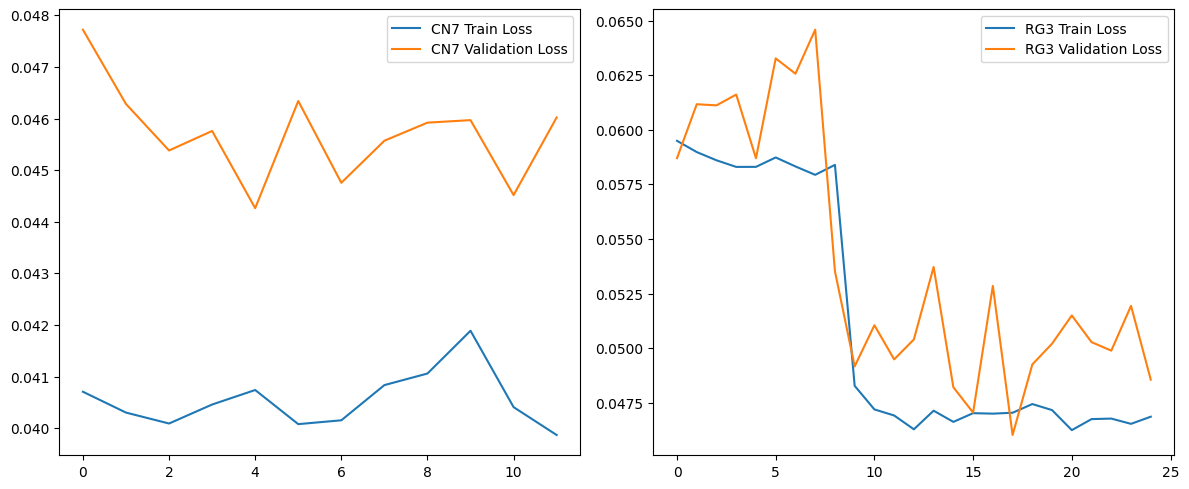

In [ ]:
# plot the training and validation loss for both autoencoders
fig, ax =plt.subplots(ncols=2, figsize=(12, 5))
ax[0].plot(history_cn7.history['loss'], label='CN7 Train Loss')
ax[0].plot(history_cn7.history['val_loss'], label='CN7 Validation Loss')
ax[0].legend()

ax[1].plot(history_rg3.history['loss'], label='RG3 Train Loss')
ax[1].plot(history_rg3.history['val_loss'], label='RG3 Validation Loss')
ax[1].legend()
plt.tight_layout()

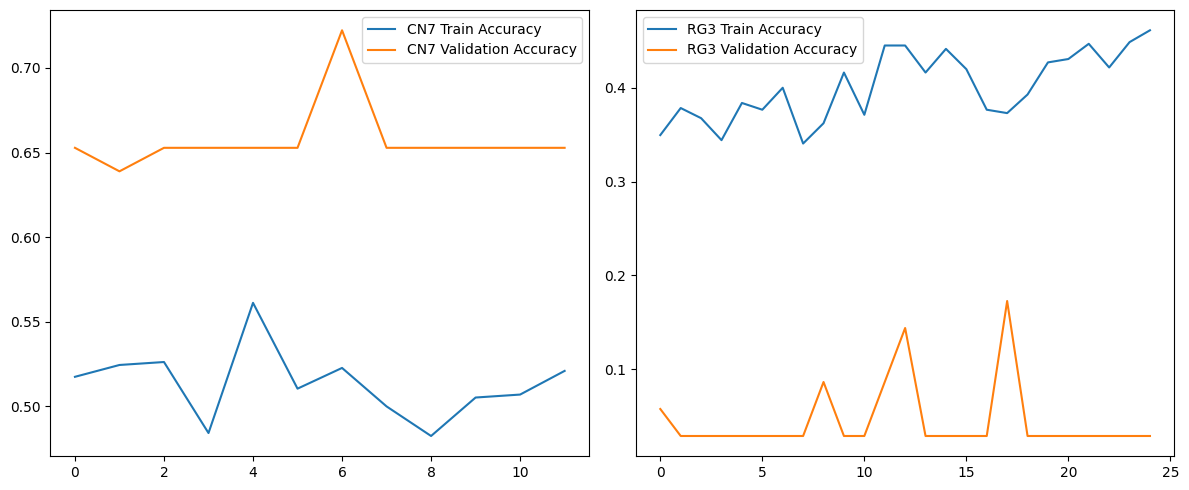

In [52]:
# plot the training and validation accuracy for both autoencoders
fig, ax =plt.subplots(ncols=2, figsize=(12, 5))
ax[0].plot(history_cn7.history['accuracy'], label='CN7 Train Accuracy')
ax[0].plot(history_cn7.history['val_accuracy'], label='CN7 Validation Accuracy')
ax[0].legend()

ax[1].plot(history_rg3.history['accuracy'], label='RG3 Train Accuracy')
ax[1].plot(history_rg3.history['val_accuracy'], label='RG3 Validation Accuracy')
ax[1].legend()

plt.tight_layout()

#### 4. 임계값 정의 및 예측값과 복원 오차 확인

**임계값 정의 가이드**

양품과 불량을 구분하기 위해서는 잡음제거 오토인코더 모델을 각각 거치고 나온 양품 데이터와 불량 데이터의 복원 오차를 구별할 수 있는 임계치가 필요함
- 양품 데이터로만 학습된 모델은 양품 데이터가 들어왔을 때 더 잘 복원해낼 것이므로 작은 복원 오차값을 가짐
- 그러나 불량 데이터가 들어왔을 때에는 덜 복원해내므로 높은 복원 오차값을 가지게 됨

**Three-sigma rule**
- 평균에서 양쪽으로 3*sigma 범위에 거의 모든 값(99.7%)가 들어간다는 가정
- 1 sigma (68.3%), 2 sigma (95.5%), 3 sigma (99.7%)
- 아래 예시에서는 5 sigma 값 사용

In [56]:
# predictions on the training set
cn7_train_pred = cn7_AE.predict(cn7_train_Y)
rg3_train_pred = rg3_AE.predict(rg3_train_Y)

# reconstruction error for the training set (prediction - original)
cn7_train_loss = np.mean(np.square(cn7_train_pred - cn7_train_Y), axis=1)
rg3_train_loss = np.mean(np.square(rg3_train_pred - rg3_train_Y), axis=1)

# threshold for anomaly detection (mean + 5*std)
cn7_threshold = np.mean(cn7_train_loss) + 5 * np.std(cn7_train_loss)
rg3_threshold = np.mean(rg3_train_loss) + 5 * np.std(rg3_train_loss)

print('CN7 복원 오류 임계치: ', cn7_threshold)
print('RG3 복원 오류 임계치: ', rg3_threshold)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 576us/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 334us/step
CN7 복원 오류 임계치:  0.10021457966615627
RG3 복원 오류 임계치:  0.1281867128146308


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 791us/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 497us/step


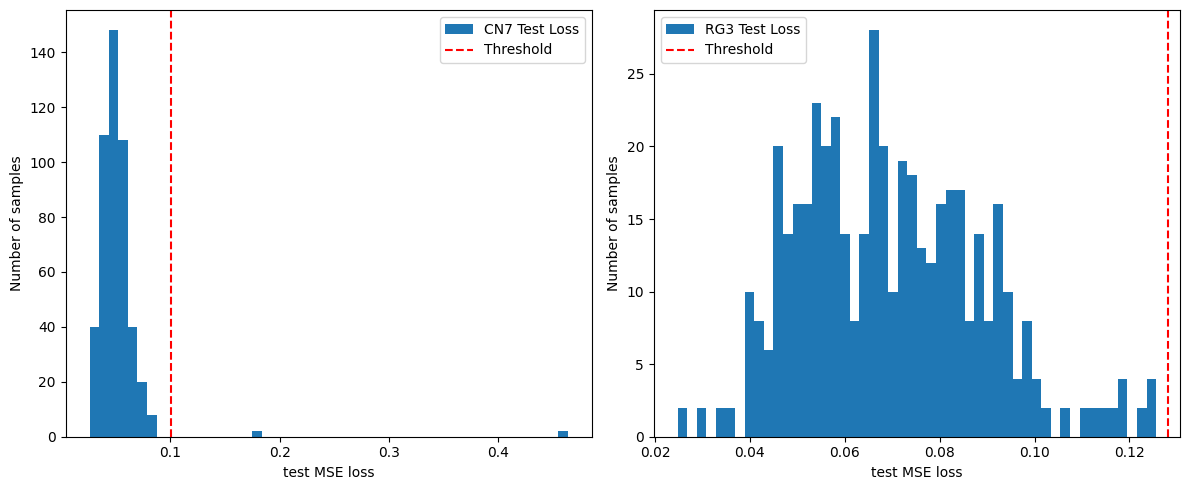

In [57]:
# prediction on the test set
cn7_predict_Y = cn7_AE.predict(cn7_test_Y)
rg3_predict_Y = rg3_AE.predict(rg3_test_Y)

# reconstruction error for the test set (prediction - original)
cn7_test_loss = np.mean(np.square(cn7_predict_Y - cn7_test_Y), axis=1)
rg3_test_loss = np.mean(np.square(rg3_predict_Y - rg3_test_Y), axis=1)

# visualization
fig, ax = plt.subplots(ncols=2, figsize=(12, 5))
ax[0].hist(cn7_test_loss, bins=50, label='CN7 Test Loss')
ax[0].set_xlabel('test MSE loss')
ax[0].set_ylabel('Number of samples')
ax[0].axvline(cn7_threshold, color='r', linestyle='--', label='Threshold')
ax[0].legend()

ax[1].hist(rg3_test_loss, bins=50, label='RG3 Test Loss')
ax[1].set_xlabel('test MSE loss')
ax[1].set_ylabel('Number of samples')
ax[1].axvline(rg3_threshold, color='r', linestyle='--', label='Threshold')
ax[1].legend()
plt.tight_layout()

In [ ]:
# 불량으로 판단한 데이터 확인
# Note that we are using the test set of Y (good products) to check for anomalies, 
# as we want to see if any good products are incorrectly classified as bad.
cn7_test_Y_anomalies = (cn7_test_loss > cn7_threshold)
rg3_test_Y_anomalies = (rg3_test_loss > rg3_threshold)
print('CN7 불량 개수:', np.sum(cn7_test_Y_anomalies))
print('RG3 불량 개수:', np.sum(rg3_test_Y_anomalies))

CN7 불량 개수: 4
RG3 불량 개수: 0


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


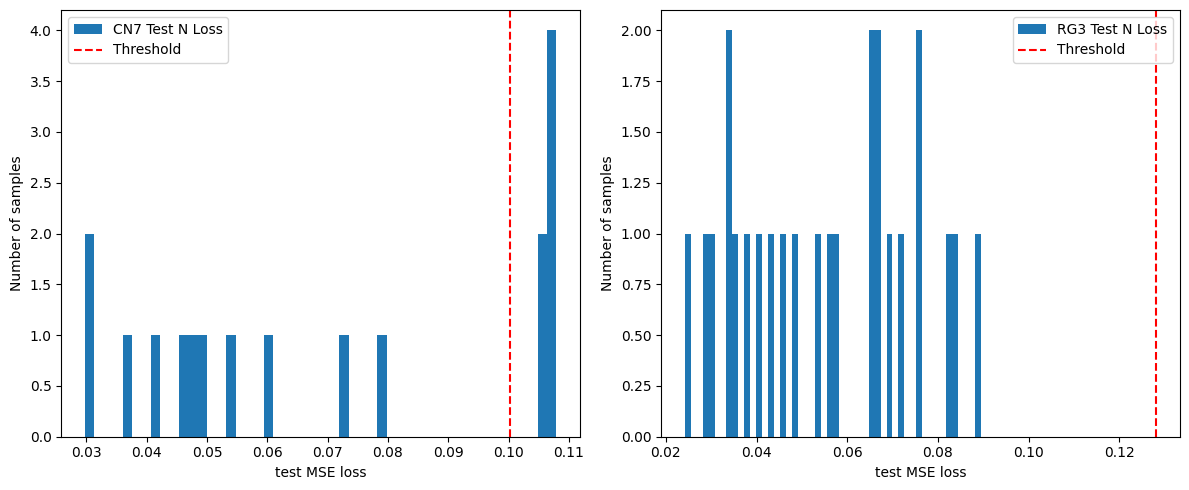

In [59]:
# prediction on test set of N (bad products)
cn7_predict_N = cn7_AE.predict(cn7_test_N)
rg3_predict_N = rg3_AE.predict(rg3_test_N)

# reconstruction error for the test set of N (prediction - original)
cn7_test_N_loss = np.mean(np.square(cn7_predict_N - cn7_test_N), axis=1)
rg3_test_N_loss = np.mean(np.square(rg3_predict_N - rg3_test_N), axis=1)

# visualization
fig, ax = plt.subplots(ncols=2, figsize=(12, 5))
ax[0].hist(cn7_test_N_loss, bins=50, label='CN7 Test N Loss')
ax[0].set_xlabel('test MSE loss')
ax[0].set_ylabel('Number of samples')
ax[0].axvline(cn7_threshold, color='r', linestyle='--', label='Threshold')
ax[0].legend()

ax[1].hist(rg3_test_N_loss, bins=50, label='RG3 Test N Loss')
ax[1].set_xlabel('test MSE loss')
ax[1].set_ylabel('Number of samples')
ax[1].axvline(rg3_threshold, color='r', linestyle='--', label='Threshold')
ax[1].legend()
plt.tight_layout()